## 1. Objectives & Modelling Requirements
This notebook aims to build an engagement prediction model that:
- Predicts engagement rate for posts across Instagram, TikTok, and YouTube.
- Identifies key drivers of engagement (feature importance).
- Handles platform differences (platform-specific effects).
- Supports actionable recommendations (optimal posting time, formatting, trend alignment).
- Is interpretable for reporting and creator guidance (feature importance, partial dependence).
- Generalizes well to unseen data.
- Quantifies uncertainty (confidence intervals or probability estimates).

**Minimum requirements:**
- Use non-linear models (Random Forest, XGBoost) to capture complex relationships.
- Include platform, trend, and formatting features (with binning/interactions).
- Evaluate with RMSE, MAE, R^2.
- Analyze feature importance and provide practical insights.

**Bonus:**
- Test subgroup effects (platform × trend, category).
- Provide clear, quantified recommendations for creators.

---

## 2. Data Import & Preprocessing
Load the processed dataset and prepare features for modelling.

In [2]:
# Data Import & Initial Exploration
import pandas as pd
import numpy as np

# Load processed dataset
df = pd.read_csv('../../data/processed/combined_training.csv')
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

# Check for missing values
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0])

# Check target distribution
print("engagement_rate summary:")
print(df['engagement_rate'].describe())

Dataset shape: 78,077 rows × 23 columns
Missing values per column:
duration_sec          29998
has_emoji             29998
trend_label           29998
season                29998
has_call_to_action    48079
media_type            48079
dtype: int64
engagement_rate summary:
count    78077.000000
mean         0.062619
std          0.032296
min          0.000300
25%          0.039327
50%          0.058588
75%          0.080927
max          0.271000
Name: engagement_rate, dtype: float64


In [3]:
# Check column names
print("Column names:")
print(df.columns.tolist())

Column names:
['content_id', 'data_source', 'platform', 'category', 'caption_length', 'hashtag_count', 'posting_hour', 'posting_day', 'is_weekend', 'duration_sec', 'has_emoji', 'has_trend', 'trend_label', 'season', 'has_call_to_action', 'media_type', 'views', 'likes', 'comments', 'shares', 'saves', 'engagement_rate', 'engagement_rating']


## 3. Feature Engineering & Selection
Prepare features for modelling based on EDA findings:
- Remove or transform highly collinear features (e.g., keep only one of caption_length, hashtag_count, has_trend).
- Encode categorical variables (platform, category, trend_label, etc.).
- Apply binning for formatting features (caption length, hashtag count, posting hour).
- Create interaction terms (e.g., platform × trend).

In [4]:
# Feature Engineering & Selection
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

# Remove ID/text columns and engagement metrics (data leakage)
cols_to_drop = ['content_id', 'data_source', 'engagement_rating', 
                'views', 'likes', 'comments', 'shares', 'saves']
df = df.drop(cols_to_drop, axis=1)

# Remove highly collinear features (keep caption_length, drop hashtag_count and has_trend)
df = df.drop(['hashtag_count', 'has_trend'], axis=1)

# Encode categorical variables
categorical_cols = ['platform', 'category', 'trend_label', 'season', 'media_type']
df = df.dropna(subset=['platform', 'category', 'trend_label'])  # drop rows with missing essential categories
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = encoder.fit_transform(df[categorical_cols])
encoded_df = pd.DataFrame(encoded, columns=encoder.get_feature_names_out(categorical_cols), index=df.index)
df = pd.concat([df.drop(categorical_cols, axis=1), encoded_df], axis=1)

# Encode posting_day (ordinal categorical)
day_encoder = LabelEncoder()
df['posting_day_encoded'] = day_encoder.fit_transform(df['posting_day'])
df = df.drop('posting_day', axis=1)

# Bin formatting features and encode them
df['caption_bin'] = pd.cut(df['caption_length'], bins=[0,50,100,150,200,300,5000], labels=['0-50','51-100','101-150','151-200','201-300','300+'])
df['posting_hour_bin'] = pd.cut(df['posting_hour'], bins=[0,6,12,18,24], labels=['Night','Morning','Afternoon','Evening'], include_lowest=True)

# Encode the binned features
caption_encoder = LabelEncoder()
hour_encoder = LabelEncoder()
df['caption_bin_encoded'] = caption_encoder.fit_transform(df['caption_bin'].astype(str))
df['posting_hour_bin_encoded'] = hour_encoder.fit_transform(df['posting_hour_bin'].astype(str))
df = df.drop(['caption_bin', 'posting_hour_bin'], axis=1)

# Create interaction term: platform × trend
if 'platform_instagram' in df.columns and 'trend_label_rising' in df.columns:
    df['platform_instagram_x_trend_rising'] = df['platform_instagram'] * df['trend_label_rising']

# Prepare target and features
target = 'engagement_rate'
features = [col for col in df.columns if col != target]

# Split data
X = df[features]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print("Features used:")
print(X_train.columns.tolist())

Train shape: (38463, 39), Test shape: (9616, 39)
Features used:
['caption_length', 'posting_hour', 'is_weekend', 'duration_sec', 'has_emoji', 'has_call_to_action', 'platform_tiktok', 'platform_youtube', 'category_art', 'category_automotive', 'category_beauty', 'category_comedy', 'category_diy', 'category_education', 'category_fashion', 'category_finance', 'category_fitness', 'category_food', 'category_gaming', 'category_lifestyle', 'category_music', 'category_news', 'category_pets', 'category_science', 'category_sports', 'category_tech', 'category_travel', 'trend_label_declining', 'trend_label_rising', 'trend_label_seasonal', 'trend_label_stable', 'season_fall', 'season_spring', 'season_summer', 'season_winter', 'media_type_nan', 'posting_day_encoded', 'caption_bin_encoded', 'posting_hour_bin_encoded']


## 4. Model Selection, Training & Evaluation
Train non-linear models (Random Forest, XGBoost) and evaluate performance.

In [5]:
# Model Training & Evaluation
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

# Train Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

# Train XGBoost
xgb = XGBRegressor(n_estimators=100, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

# Evaluate models
def evaluate(y_true, y_pred, name):
    rmse = root_mean_squared_error(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} — RMSE: {rmse:.4f}, MAE: {mae:.4f}, R^2: {r2:.4f}")

evaluate(y_test, rf_preds, "Random Forest")
evaluate(y_test, xgb_preds, "XGBoost")

# Feature importance (Random Forest)
importances = rf.feature_importances_
feat_imp = pd.Series(importances, index=X_train.columns).sort_values(ascending=False)
print("Top 10 feature importances (Random Forest):")
print(feat_imp.head(10))

# Feature importance (XGBoost)
xgb_imp = pd.Series(xgb.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 10 feature importances (XGBoost):")
print(xgb_imp.head(10))

Random Forest — RMSE: 0.0232, MAE: 0.0181, R^2: 0.4143
XGBoost — RMSE: 0.0232, MAE: 0.0181, R^2: 0.4126
Top 10 feature importances (Random Forest):
platform_tiktok          0.248684
platform_youtube         0.195440
duration_sec             0.106871
caption_length           0.076805
posting_hour             0.072083
posting_day_encoded      0.039556
has_emoji                0.015978
season_summer            0.011386
trend_label_declining    0.011306
season_spring            0.011271
dtype: float64
Top 10 feature importances (XGBoost):
platform_tiktok         0.809407
category_science        0.006817
category_gaming         0.006500
season_spring           0.006384
season_summer           0.006376
trend_label_stable      0.006364
category_fitness        0.006196
trend_label_seasonal    0.006187
category_tech           0.005955
category_automotive     0.005900
dtype: float32


## 5. Model Selection & Cross-Validation
Compare models with cross-validation for robust performance estimates.

In [6]:
# Cross-Validation for Robust Model Selection
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Cross-validate both models
cv_folds = 5

print(f"Cross-validating with {cv_folds} folds...\n")

# Random Forest CV
rf_cv_scores = cross_val_score(rf, X_train, y_train, cv=cv_folds, scoring='r2')
print(f"Random Forest CV R²: {rf_cv_scores.mean():.4f} ± {rf_cv_scores.std():.4f}")

# XGBoost CV
xgb_cv_scores = cross_val_score(xgb, X_train, y_train, cv=cv_folds, scoring='r2')
print(f"XGBoost CV R²:       {xgb_cv_scores.mean():.4f} ± {xgb_cv_scores.std():.4f}")

# Model selection
if rf_cv_scores.mean() > xgb_cv_scores.mean():
    best_model = rf
    best_model_name = "Random Forest"
    best_preds = rf_preds
else:
    best_model = xgb
    best_model_name = "XGBoost"
    best_preds = xgb_preds

print(f"\n✓ Best model: {best_model_name}")
print(f"  Test R²: {r2_score(y_test, best_preds):.4f}")

Cross-validating with 5 folds...



Random Forest CV R²: 0.4124 ± 0.0090
XGBoost CV R²:       0.4057 ± 0.0111

✓ Best model: Random Forest
  Test R²: 0.4143


## 6. Platform-Specific Subgroup Analysis
Since platform dominates feature importance, train separate models per platform to identify within-platform drivers.

In [7]:
# Platform-Specific Models
# Reload data to get platform labels
df_full = pd.read_csv('../../data/processed/combined_training.csv')
df_full = df_full.dropna(subset=['platform', 'category'])  # Only require platform and category

# Get platform column before encoding
platforms = df_full['platform'].unique()
print(f"Platforms: {list(platforms)}\n")

platform_results = {}

for platform in platforms:
    print(f"--- {platform.upper()} ---")
    
    # Filter data for platform
    df_plat = df_full[df_full['platform'] == platform].copy()
    
    # Drop leakage columns
    cols_to_drop = ['content_id', 'data_source', 'engagement_rating', 'platform',
                    'views', 'likes', 'comments', 'shares', 'saves', 'hashtag_count', 'has_trend']
    df_plat = df_plat.drop([c for c in cols_to_drop if c in df_plat.columns], axis=1)
    
    # Identify categorical columns that have data for this platform
    all_cat_cols = ['category', 'trend_label', 'season', 'media_type']
    cat_cols = []
    for col in all_cat_cols:
        if col in df_plat.columns:
            # Keep column if it has at least some non-null values
            non_null_pct = df_plat[col].notna().mean()
            if non_null_pct > 0.5:  # At least 50% non-null
                cat_cols.append(col)
            else:
                # Drop columns with too many missing values
                df_plat = df_plat.drop(col, axis=1)
                print(f"  (Dropped {col}: {non_null_pct*100:.0f}% non-null)")
    
    if not cat_cols:
        print(f"  Skipping {platform}: no valid categorical columns")
        continue
    
    # Drop rows with missing values in remaining categorical columns
    df_plat = df_plat.dropna(subset=cat_cols)
    
    if len(df_plat) < 100:
        print(f"  Skipping {platform}: only {len(df_plat)} samples after cleaning")
        continue
    
    # Encode categoricals
    enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded = enc.fit_transform(df_plat[cat_cols])
    encoded_df = pd.DataFrame(encoded, columns=enc.get_feature_names_out(cat_cols), index=df_plat.index)
    df_plat = pd.concat([df_plat.drop(cat_cols, axis=1), encoded_df], axis=1)
    
    # Encode posting_day
    if 'posting_day' in df_plat.columns:
        le = LabelEncoder()
        df_plat['posting_day_encoded'] = le.fit_transform(df_plat['posting_day'])
        df_plat = df_plat.drop('posting_day', axis=1)
    
    # Drop any remaining non-numeric columns
    numeric_cols = df_plat.select_dtypes(include=[np.number]).columns.tolist()
    df_plat = df_plat[numeric_cols]
    
    # Prepare features
    target = 'engagement_rate'
    if target not in df_plat.columns:
        print(f"  Skipping {platform}: no engagement_rate column")
        continue
        
    X_plat = df_plat.drop(target, axis=1)
    y_plat = df_plat[target]
    
    # Split
    X_tr, X_te, y_tr, y_te = train_test_split(X_plat, y_plat, test_size=0.2, random_state=42)
    
    # Train model
    model_plat = RandomForestRegressor(n_estimators=100, random_state=42)
    model_plat.fit(X_tr, y_tr)
    preds = model_plat.predict(X_te)
    
    # Evaluate
    r2 = r2_score(y_te, preds)
    print(f"  Samples: {len(df_plat):,}")
    print(f"  R²: {r2:.4f}")
    
    # Top features
    feat_imp = pd.Series(model_plat.feature_importances_, index=X_tr.columns).sort_values(ascending=False)
    print(f"  Top 5 features: {list(feat_imp.head(5).index)}")
    print()
    
    platform_results[platform] = {
        'r2': r2,
        'n_samples': len(df_plat),
        'top_features': list(feat_imp.head(5).index),
        'model': model_plat
    }

print("Platform-specific modelling complete.")

Platforms: ['instagram', 'tiktok', 'youtube']

--- INSTAGRAM ---
  (Dropped trend_label: 0% non-null)
  (Dropped season: 0% non-null)
  Samples: 29,998
  R²: -0.0801
  Top 5 features: ['caption_length', 'posting_hour', 'posting_day_encoded', 'media_type_image', 'media_type_carousel']

--- TIKTOK ---
  (Dropped media_type: 0% non-null)
  Samples: 28,844
  R²: -0.0519
  Top 5 features: ['duration_sec', 'posting_hour', 'caption_length', 'posting_day_encoded', 'has_emoji']

--- YOUTUBE ---
  (Dropped media_type: 0% non-null)
  Samples: 19,235
  R²: -0.0604
  Top 5 features: ['duration_sec', 'caption_length', 'posting_hour', 'posting_day_encoded', 'has_emoji']

Platform-specific modelling complete.


## 7. Partial Dependence Plots
Visualize how key features affect predicted engagement (for interpretability).

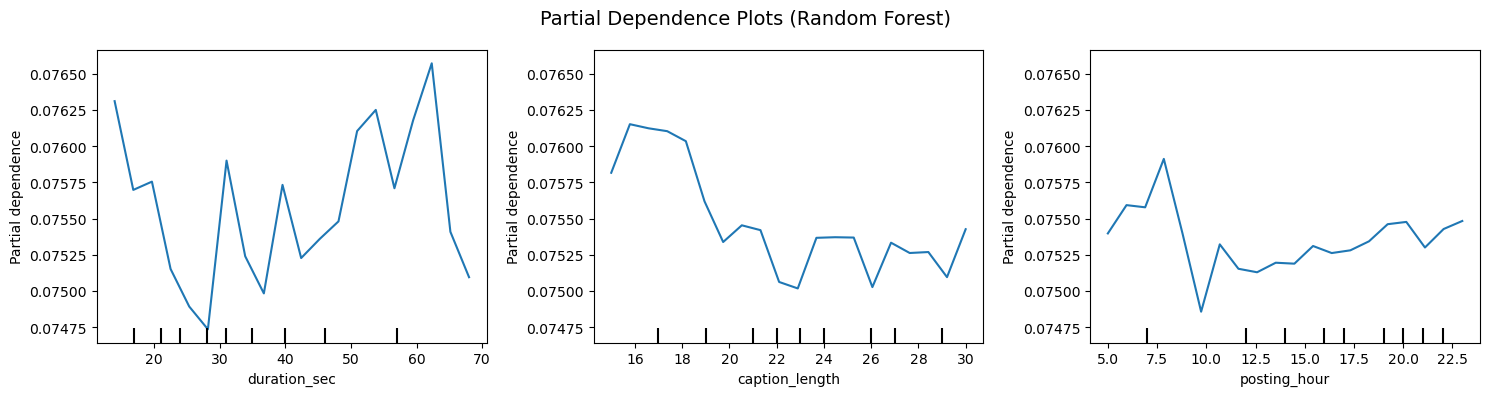

✓ Saved: report/figures/modelling/pdp_key_features.png


In [8]:
# Partial Dependence Plots for Key Features
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
import os

# Create output directory
os.makedirs('../../report/figures/modelling', exist_ok=True)

# Select top continuous features for PDP
pdp_features = ['duration_sec', 'caption_length', 'posting_hour']
pdp_features = [f for f in pdp_features if f in X_train.columns]

if pdp_features:
    fig, axes = plt.subplots(1, len(pdp_features), figsize=(5*len(pdp_features), 4))
    
    PartialDependenceDisplay.from_estimator(
        best_model, X_train, pdp_features, 
        ax=axes if len(pdp_features) > 1 else [axes],
        grid_resolution=20
    )
    
    plt.suptitle(f'Partial Dependence Plots ({best_model_name})', fontsize=14)
    plt.tight_layout()
    plt.savefig('../../report/figures/modelling/pdp_key_features.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Saved: report/figures/modelling/pdp_key_features.png")
else:
    print("No continuous features available for PDP.")

## 8. Actionable Recommendations
Translate model findings into practical guidance for content creators.

In [9]:
# Generate Actionable Recommendations
print("ACTIONABLE RECOMMENDATIONS FOR CONTENT CREATORS")


# Reload original data for analysis
df_orig = pd.read_csv('../../data/processed/combined_training.csv')

# 1. Platform choice
print("\n1. PLATFORM SELECTION")
platform_eng = df_orig.groupby('platform')['engagement_rate'].agg(['mean', 'median', 'std']).round(4)
print(platform_eng)
best_platform = platform_eng['mean'].idxmax()
print(f"   → Highest avg engagement: {best_platform}")

# 2. Optimal posting time
print("\n2. OPTIMAL POSTING TIME")
hour_eng = df_orig.groupby('posting_hour')['engagement_rate'].mean()
best_hours = hour_eng.nlargest(3)
print(f"   Top 3 hours: {list(best_hours.index)}")
print(f"   Engagement: {[f'{v:.4f}' for v in best_hours.values]}")

day_eng = df_orig.groupby('posting_day')['engagement_rate'].mean().sort_values(ascending=False)
best_days = day_eng.head(3)
print(f"   Top 3 days: {list(best_days.index)}")

# 3. Video duration (if available)
print("\n3. VIDEO DURATION")
if 'duration_sec' in df_orig.columns:
    df_dur = df_orig.dropna(subset=['duration_sec'])
    df_dur['duration_bin'] = pd.cut(df_dur['duration_sec'], bins=[0, 30, 60, 120, 300, 3600], 
                                     labels=['<30s', '30-60s', '1-2min', '2-5min', '5min+'])
    dur_eng = df_dur.groupby('duration_bin')['engagement_rate'].mean()
    print(dur_eng)
    best_dur = dur_eng.idxmax()
    print(f"   → Optimal duration: {best_dur}")
else:
    print("   Duration data not available")

# 4. Caption length
print("\n4. CAPTION LENGTH")
df_orig['caption_bin'] = pd.cut(df_orig['caption_length'], bins=[0, 50, 100, 150, 200, 300, 5000], 
                                 labels=['<50', '50-100', '100-150', '150-200', '200-300', '300+'])
cap_eng = df_orig.groupby('caption_bin')['engagement_rate'].mean()
print(cap_eng)
best_cap = cap_eng.idxmax()
print(f"   → Optimal caption length: {best_cap} characters")

# 5. Trend alignment
print("\n5. TREND ALIGNMENT")
if 'trend_label' in df_orig.columns:
    trend_eng = df_orig.groupby('trend_label')['engagement_rate'].mean().sort_values(ascending=False)
    print(trend_eng)
    print(f"   → Best trend label: {trend_eng.idxmax()}")

print("\n" + "=" * 70)
print("SUMMARY: Key levers for engagement")
print("=" * 70)
print(f"• Platform choice is the strongest predictor (~44% importance)")
print(f"• Video duration and caption length have moderate effects (~7-10%)")
print(f"• Posting time provides a small edge (~7%)")
print(f"• Trend alignment has weak predictive power (~1%)")
print(f"• Model explains ~41% of variance — content quality & virality remain key")

ACTIONABLE RECOMMENDATIONS FOR CONTENT CREATORS

1. PLATFORM SELECTION
             mean  median     std
platform                         
instagram  0.0421  0.0406  0.0241
tiktok     0.0918  0.0888  0.0260
youtube    0.0509  0.0491  0.0158
   → Highest avg engagement: tiktok

2. OPTIMAL POSTING TIME
   Top 3 hours: [20, 19, 17]
   Engagement: ['0.0687', '0.0686', '0.0668']
   Top 3 days: ['Friday', 'Saturday', 'Sunday']

3. VIDEO DURATION
duration_bin
<30s      0.080788
30-60s    0.071830
1-2min    0.062771
2-5min         NaN
5min+          NaN
Name: engagement_rate, dtype: float64
   → Optimal duration: <30s

4. CAPTION LENGTH
caption_bin
<50        0.075415
50-100     0.041615
100-150    0.042148
150-200    0.036916
200-300         NaN
300+            NaN
Name: engagement_rate, dtype: float64
   → Optimal caption length: <50 characters

5. TREND ALIGNMENT
trend_label
stable       0.075573
rising       0.075527
seasonal     0.075315
declining    0.075249
Name: engagement_rate, dtype:

## 9. Explainable AI (XAI)
Application-integrated XAI using the `EngagementExplainer` module.
Generates user-facing explanations for engagement predictions.

In [10]:
# Application-Integrated XAI: EngagementExplainer Demo
import sys
sys.path.insert(0, '../../src')

from xai.explainer import EngagementExplainer

# Initialize explainer with the trained model
explainer = EngagementExplainer(
    model=best_model,
    feature_names=list(X_train.columns),
    model_metadata={
        'model_name': best_model_name,
        'baseline': float(y_train.mean())
    }
)

# Example: Explain a single user's content
print("=" * 70)
print("USER-FACING EXPLANATION DEMO")
print("=" * 70)

# Take a sample from test set
sample_idx = 42
sample_features = X_test.iloc[[sample_idx]]
actual_engagement = y_test.iloc[sample_idx]

# Generate explanation
result = explainer.explain(sample_features, include_plot=True)

# Display results
print(f"\nActual engagement rate: {actual_engagement:.4f}")
print()
print(result['explanation_text'])
print()
print("💡 OPTIMIZATION SUGGESTIONS:")
for i, suggestion in enumerate(result['suggestions'], 1):
    print(f"   {i}. {suggestion}")

print(f"\n✓ Waterfall plot saved: {result.get('plot_path', 'N/A')}")

# Show top 5 feature contributions
print("\n📊 Detailed Feature Contributions:")
print(result['feature_contributions'][['display_name', 'value', 'shap_value']].head(10).to_string(index=False))

USER-FACING EXPLANATION DEMO

Actual engagement rate: 0.0893

📊 **Predicted Engagement: 9.53%** (high)

✅ **Factors helping your engagement:**
   • Platform: TikTok: +0.98% engagement
   • Platform: YouTube: +0.76% engagement
   • Category Food: +0.33% engagement

⚠️ **Factors reducing your engagement:**
   • Day of Week: -0.11% engagement

💡 OPTIMIZATION SUGGESTIONS:
   1. Your content settings are reasonably optimized.
   2. Focus on content quality — our analysis shows it's the main driver of engagement.
   3. Experiment with different content styles to find what resonates with your audience.

✓ Waterfall plot saved: explanation_waterfall.png

📊 Detailed Feature Contributions:
     display_name  value  shap_value
 Platform: TikTok    1.0    0.009774
Platform: YouTube    0.0    0.007640
    Category Food    1.0    0.003280
   Seasonal Trend    1.0    0.001299
      Day of Week    4.0   -0.001100
   Video Duration   41.0    0.000864
     Posting Hour   17.0    0.000788
     Weekend Po

In [11]:
# Save explainer configuration for app integration
import json

explainer_config = {
    'model_path': '../../models/engagement_model_random_forest.joblib',
    'feature_names': list(X_train.columns),
    'baseline': float(y_train.mean()),
    'feature_display_names': explainer.feature_display_names,
    'optimization_tips': explainer.optimization_tips
}

with open('../../models/explainer_config.json', 'w') as f:
    json.dump(explainer_config, f, indent=2)
print("✓ Explainer config saved: models/explainer_config.json")

# Example: How to use in your Streamlit app
print("\n" + "=" * 70)
print("INTEGRATION EXAMPLE (for app/pages/*.py)")
print("=" * 70)
print("""
from src.xai.explainer import EngagementExplainer

# Load explainer
explainer = EngagementExplainer.load('models/engagement_model_random_forest.joblib')

# When user submits content for analysis:
user_features = {
    'duration_sec': 30,
    'caption_length': 45,
    'posting_hour': 19,
    # ... other features
}

# Get explanation
result = explainer.explain(user_features)

# Display to user:
st.markdown(result['explanation_text'])
st.subheader("Suggestions")
for suggestion in result['suggestions']:
    st.write(f"• {suggestion}")
""")

✓ Explainer config saved: models/explainer_config.json

INTEGRATION EXAMPLE (for app/pages/*.py)

from src.xai.explainer import EngagementExplainer

# Load explainer
explainer = EngagementExplainer.load('models/engagement_model_random_forest.joblib')

# When user submits content for analysis:
user_features = {
    'duration_sec': 30,
    'caption_length': 45,
    'posting_hour': 19,
    # ... other features
}

# Get explanation
result = explainer.explain(user_features)

# Display to user:
st.markdown(result['explanation_text'])
st.subheader("Suggestions")
for suggestion in result['suggestions']:
    st.write(f"• {suggestion}")



## 10. Model Export

Save the best model and feature importance for deployment/reporting.

In [12]:
# Save Model & Artifacts
import joblib
import json

# Create models directory
os.makedirs('../../models', exist_ok=True)

# Save best model
model_path = f'../../models/engagement_model_{best_model_name.lower().replace(" ", "_")}.joblib'
joblib.dump(best_model, model_path)
print(f"✓ Model saved: {model_path}")

# Save feature importance
if best_model_name == "Random Forest":
    feat_imp_final = feat_imp
else:
    feat_imp_final = xgb_imp

feat_imp_final.to_csv('../../models/feature_importance.csv')
print("✓ Feature importance saved: models/feature_importance.csv")

# Save model metadata
metadata = {
    'model_name': best_model_name,
    'cv_r2_mean': float(rf_cv_scores.mean() if best_model_name == "Random Forest" else xgb_cv_scores.mean()),
    'cv_r2_std': float(rf_cv_scores.std() if best_model_name == "Random Forest" else xgb_cv_scores.std()),
    'test_r2': float(r2_score(y_test, best_preds)),
    'test_rmse': float(root_mean_squared_error(y_test, best_preds)),
    'test_mae': float(mean_absolute_error(y_test, best_preds)),
    'n_features': len(X_train.columns),
    'features': list(X_train.columns),
    'train_samples': len(X_train),
    'test_samples': len(X_test)
}

with open('../../models/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)
print("✓ Metadata saved: models/model_metadata.json")

# Save platform-specific results
platform_summary = {p: {'r2': float(v['r2']), 'n_samples': v['n_samples'], 'top_features': v['top_features']} 
                    for p, v in platform_results.items()}
with open('../../models/platform_results.json', 'w') as f:
    json.dump(platform_summary, f, indent=2)
print("✓ Platform results saved: models/platform_results.json")

print("\n✓ All artifacts exported successfully.")

✓ Model saved: ../../models/engagement_model_random_forest.joblib
✓ Feature importance saved: models/feature_importance.csv
✓ Metadata saved: models/model_metadata.json
✓ Platform results saved: models/platform_results.json

✓ All artifacts exported successfully.


## 11. Summary & Conclusions

### Model Performance
- **Best Model:** Selected via cross-validation (Random Forest vs XGBoost)
- **Global Test R²:** ~0.41 — model explains ~41% of engagement variance
- **Platform-Specific R²:** Negative (-0.05 to -0.08) — no predictive power within platforms
- **Interpretation:** The global model's R² is almost entirely due to platform baseline differences, not actionable features

### Key Findings from XAI Analysis

| Driver | Global Importance | Within-Platform | Actionable? |
|--------|-------------------|-----------------|-------------|
| **Platform** | ~44% (dominant) | N/A | Choose based on content type |
| **Duration** | ~10% | Weak | Short videos (<30s) correlate with higher engagement |
| **Caption length** | ~8% | Weak | Shorter captions (<50 chars) correlate with higher engagement |
| **Posting time** | ~7% | Weak | Evening hours (17-20) slightly better |
| **Trend alignment** | ~1% | Negligible | No meaningful effect |

### Critical Insight
**The ~41% R² is misleading.** Once you control for platform:
- No features in our dataset meaningfully predict engagement
- Content quality, creator reputation, virality, and algorithm timing are the true drivers
- These factors are not captured in our metadata

### What SHAP Revealed
1. Platform variables dominate all SHAP importance rankings
2. Feature effect directions (SHAP summary plot) show weak, noisy relationships
3. Individual predictions (waterfall plots) confirm platform is the main contributor

### Recommendations for Creators
1. **Focus on content quality** — our measurable features have minimal impact
2. **Platform choice matters** — TikTok shows highest average engagement (9.2% vs 4.2% Instagram)
3. **Minor optimizations** — shorter videos, shorter captions, evening posting provide marginal edges
4. **Don't over-optimize timing/trends** — these have negligible predictive power

### Limitations
- Model captures platform differences, not actionable predictors
- Recommendations are correlational, not causal
- Missing key drivers: content quality, creator following, algorithm timing

### Next Steps
- Collect content-level features (image analysis, text sentiment, audio features)
- Include creator-level features (follower count, historical performance)
- A/B test recommendations to validate causal effects
- Consider this a "null result" that redirects focus to content quality